# Notebook 7  - Ground Truth Room Label Rasterizer

**Stage GT file · runs after Notebook 1**

> **Pipeline execution order: `6 -> 1 -> 2 -> 4 -> 7 -> 8`.**
> Notebook 7 reads the ground-truth model's per-room, **per-class** annotations
> (`groundtruth.gt_dir`), keeps each room's **interior area** points and rasterises them onto the
> **exact Stage 1 pixel grid** (via `transform.json`), producing a ground-truth room-label map in
> the same shape + coordinate frame as the watershed's `room_labels.npy`. Notebook 8 scores the
> predictions against it.

## Purpose
Build `gt_room_labels.npy`: per-pixel ground-truth room membership on the Stage 1 grid, where a
room is its **indoor area only** (research-fixes Task 02).

## Inputs
- `stage1_occupancy/transform.json`  - the pixel<->world grid (Notebook 1), built from the scan.
- `<gt_dir>/<room>/Annotations/<class>_*.txt`  - each room's S3DIS per-class point files (`X Y Z
  R G B`). `gt_dir` is `groundtruth.gt_dir` in `params.yaml` (must match the scan's frame  - see
  the gate below). The builder keeps the interior classes and drops the structural + clutter
  classes (`scan2bim.STRUCTURAL_CLUTTER_CLASSES`). Rooms without an `Annotations/` dir fall back
  to the whole-room `<room>/<room>.txt` (then walls/clutter can't be excluded  - flagged via an
  empty `kept classes`).

## Outputs  (`{out_root}/stage_gt/`)
- `gt_room_labels.npy`  - int32, shape `(H, W)`: `0` = exterior, `>=1` = room id.
- `gt_room_labels_color.png`  - colourised QA image.

## Assumptions
- Notebook 1 has been run on the scan (`input.file_path`), so `transform.json` is in the scan's
  frame, and `groundtruth.gt_dir` points at the GT for **that same scene** (Step 3.5 asserts the
  two share a frame; a mismatch hard-fails). Each room folder gets a 1-based id (sorted folder
  order), matching the `>=1 == room` convention of `room_labels.npy`.
- The GT room region is **interior space**  - `wall`/`beam`/`column`/`door`/`window`/`clutter`
  points are excluded so the GT matches the methods' `-1` wall convention. Walls are **not**
  marked `-1` here; the shared wall scaffold is applied at scoring time (Notebook 8).

### Setup
**Run-All ready.** Edit **`params.yaml`** (the only config surface), then run every cell top
to bottom. `load_config()` reads it over the `Config` defaults.

In [7]:
import sys, os
import numpy as np

PROJECT_ROOT = os.path.abspath('../..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
sys.path = [p for p in sys.path if not p.endswith('/src') and not p.endswith('\\src')]
for mod in list(sys.modules):
    if mod == 'scan2bim' or mod.startswith('scan2bim.'):
        del sys.modules[mod]

import scan2bim
from scan2bim import artifacts as A

CFG = scan2bim.load_config()
SHOW_DEBUG = True
ROOT = scan2bim.project_root()
AREA_DIR = CFG.gt_dir
STAGE_GT = 'stage_gt'
GT_MIN_INGRID_FRAC = 0.98
print('scan2bim', scan2bim.__version__, 'loaded from', os.path.dirname(scan2bim.__file__))
print('scan (Stage 1):', CFG.file_path)
print('GT dir        :', AREA_DIR, '| exists:', os.path.isdir(AREA_DIR))
print('output root   :', CFG.out_root)

scan2bim 1.0.0 loaded from c:\onestruction\scan2bim
scan (Stage 1): c:\onestruction\data\area1.xyz
GT dir        : c:\onestruction\data\Area_1 | exists: True
output root   : c:\onestruction\scan2bim_out


### Step 1  - Load the Stage 1 grid (`transform.json`)
The GT must align pixel-for-pixel with the watershed output, so it is projected through the
**same** transform Notebook 1 wrote.

In [8]:
s1 = A.load_stage_dir(CFG.out_root, A.STAGE1)
tf = A.load_transform(os.path.join(s1, A.TRANSFORM_JSON))
H, W = tf['height'], tf['width']
print('grid (H x W):', (H, W), '| pixel_size:', tf['pixel_size'], 'm')

grid (H x W): (1606, 1618) | pixel_size: 0.03 m


### Step 3  - Build clean GT room labels (interior area only)
`scan2bim.build_gt_room_labels` reads each room's per-class `Annotations/<class>_*.txt`, keeps
only the **interior** classes (`floor`/`ceiling`/`board`/furniture/…) and **drops the structural
+ clutter** classes (`wall`/`beam`/`column`/`door`/`window`/`clutter`, see
`scan2bim.STRUCTURAL_CLUTTER_CLASSES`), then rasterises the kept points onto the Stage-1 grid via
`point_cells`. This matches the paper's *indoor-area* room region and the methods' `-1` wall
convention  - so the GT never penalises a method for correctly marking a wall as not-room. Rooms
get a 1-based id in sorted folder order; pixels no room hits stay `0` (exterior); walls are **not**
marked `-1` here (the shared wall scaffold is applied at scoring time, Notebook 8).

In [9]:
# Build CLEAN GT room labels: each room's INTERIOR points only (structural + clutter classes
# dropped) rasterised onto the Stage-1 grid. All logic lives in scan2bim.eval.build_gt_room_labels
# (pure + unit-tested); this notebook is a thin driver. See scan2bim.STRUCTURAL_CLUTTER_CLASSES.
gt_labels, gt_info = scan2bim.build_gt_room_labels(AREA_DIR, tf)

print('excluded classes (NOT room area):', ', '.join(scan2bim.STRUCTURAL_CLUTTER_CLASSES))
print('%-18s %4s  %9s  %7s  %-7s  %s' % ('room', 'id', 'pts', 'in-grid', 'frac', 'kept classes'))
for r in gt_info['rooms']:
    print('%-18s %4d  %9d  %7d  %5.1f%%  %s'
          % (r['name'], r['id'], r['n_pts'], r['n_inb'], 100.0 * r['frac'], ', '.join(r['classes'])))

excluded classes (NOT room area): wall, beam, column, door, window, clutter
room                 id        pts  in-grid  frac     kept classes
WC_1                  1     377803   377803  100.0%  ceiling, floor
conferenceRoom_1      2     619538   619538  100.0%  board, bookcase, ceiling, chair, floor, table
conferenceRoom_2      3     952625   952625  100.0%  board, bookcase, ceiling, chair, floor, sofa, table
copyRoom_1            4     242171   242171  100.0%  bookcase, ceiling, floor, table
hallway_1             5     127913   127913  100.0%  ceiling, floor
hallway_2             6     216493   216493  100.0%  ceiling, floor
hallway_3             7     132199   132199  100.0%  ceiling, floor
hallway_4             8     116120   116120  100.0%  ceiling, floor
hallway_5             9     170447   170447  100.0%  ceiling, floor
hallway_6            10    2057172  2057172  100.0%  bookcase, ceiling, floor
hallway_7            11    1577090  1573450   99.8%  bookcase, ceiling, floor
hall

### Step 3.5  - Coordinate-frame alignment gate (HARD FAIL)  ·  research-fixes Task 01
The scan (Stage 1) and the GT model (`gt_dir`) are sourced independently, so nothing
structurally guarantees they share a world frame. Before any pixel of this GT is trusted,
assert that the GT room points back-project into the scan's Stage-1 grid with a high in-bounds
fraction (`GT_MIN_INGRID_FRAC`, default 98%). A mismatched scan/GT pair (e.g. `area1.xyz` with
the wrong area's GT) lands far below that and **raises here** instead of silently producing
meaningless IoU/PQ. The printed GT-vs-grid bounding boxes let a human eyeball the overlap.

In [10]:
frac = gt_info['ingrid_frac']
ga0, gb0, ga1, gb1 = scan2bim.grid_world_bbox(tf)          # scan's Stage-1 grid, world units
gla0, glb0, gla1, glb1 = gt_info['gt_bbox']                # GT interior-point bbox over (ax_a, ax_b)
print('GT in-grid fraction : %.2f%%  (gate >= %.0f%%)' % (100 * frac, 100 * GT_MIN_INGRID_FRAC))
print('GT   bbox  axis-a [% .3f, % .3f]  axis-b [% .3f, % .3f]' % (gla0, gla1, glb0, glb1))
print('grid bbox  axis-a [% .3f, % .3f]  axis-b [% .3f, % .3f]' % (ga0, ga1, gb0, gb1))
if frac < GT_MIN_INGRID_FRAC:
    raise ValueError(
        'Frame mismatch: only %.1f%% of the GT points (%s) fall inside the scan\'s Stage-1 grid '
        '(built from %s)  - need >= %.0f%%. The scan and the GT are almost certainly DIFFERENT '
        'scenes/frames. Point groundtruth.gt_dir at the GT that matches input.file_path (and '
        're-run Notebook 1 if you changed the scan), then re-run this notebook.'
        % (100 * frac, AREA_DIR, CFG.file_path, 100 * GT_MIN_INGRID_FRAC))
print('OK  - GT and scan share the coordinate frame; GT is safe to score against.')

GT in-grid fraction : 99.98%  (gate >= 98%)
GT   bbox  axis-a [-33.860,  14.809]  axis-b [-2.139,  46.042]
grid bbox  axis-a [-33.856,  14.684]  axis-b [-2.138,  46.042]
OK  - GT and scan share the coordinate frame; GT is safe to score against.


### Step 4  - Save GT labels + colourised PNG

In [11]:
out_dir = A.ensure_dir(A.stage_dir(CFG.out_root, STAGE_GT))
gt_npy = os.path.join(out_dir, 'gt_room_labels.npy')
A.save_npy(gt_npy, gt_labels)
A.save_label_png(os.path.join(out_dir, 'gt_room_labels_color.png'), gt_labels)
ids = [int(v) for v in np.unique(gt_labels) if v >= 1]
print('unique room ids in GT:', len(ids), '->', ids)
print('packaged ->', gt_npy)

unique room ids in GT: 44 -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44]
packaged -> c:\onestruction\scan2bim_out\stage_gt\gt_room_labels.npy


### Optional  - QA plot (GT vs. the Stage 2 watershed rooms)

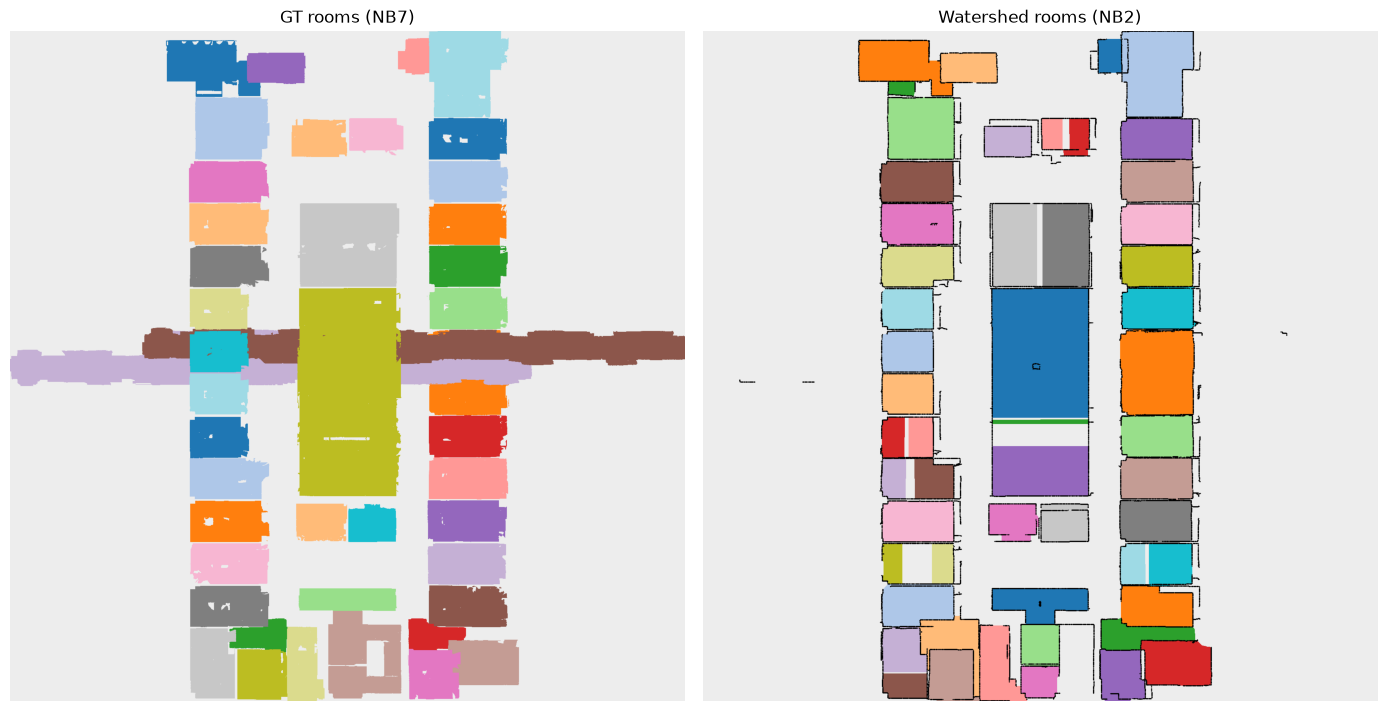

QA GATE  - verify before reporting ANY pq_eval metric:
  [ ] The GT rooms (left) and watershed rooms (right) occupy the SAME footprint /
      orientation  - no global flip, rotation, or XY offset between the two panels.
  [ ] Room boundaries broadly coincide (per-room IoU is expected to be imperfect, but
      the building outline and corridor layout must clearly overlap, not sit side by side).
  [ ] The Step 3.5 in-grid gate above printed OK (>= 98%).
If any box is unchecked, STOP  - fix the scan/GT pairing (params.yaml) before scoring.


In [12]:
if SHOW_DEBUG:
    import matplotlib.pyplot as plt
    from PIL import Image
    gt_img = Image.open(os.path.join(out_dir, 'gt_room_labels_color.png'))
    s2 = A.load_stage_dir(CFG.out_root, A.STAGE2)
    geom_img = Image.open(os.path.join(s2, A.ROOM_LABELS_PNG))
    fig, ax = plt.subplots(1, 2, figsize=(14, 7))
    ax[0].imshow(gt_img);  ax[0].set_title('GT rooms (NB7)');        ax[0].axis('off')
    ax[1].imshow(geom_img); ax[1].set_title('Watershed rooms (NB2)'); ax[1].axis('off')
    plt.tight_layout(); plt.show()

# --- QA gate (research-fixes Task 01): visual coincidence is a REQUIRED check ----------
# The numeric in-grid gate above proves the GT and scan share a frame; it does NOT prove the
# rasterised GT footprint lines up with the segmentation. Confirm the two panels above before
# trusting any pq_eval number.
print('QA GATE  - verify before reporting ANY pq_eval metric:')
print('  [ ] The GT rooms (left) and watershed rooms (right) occupy the SAME footprint /')
print('      orientation  - no global flip, rotation, or XY offset between the two panels.')
print('  [ ] Room boundaries broadly coincide (per-room IoU is expected to be imperfect, but')
print('      the building outline and corridor layout must clearly overlap, not sit side by side).')
print('  [ ] The Step 3.5 in-grid gate above printed OK (>= %.0f%%).' % (100 * GT_MIN_INGRID_FRAC))
print('If any box is unchecked, STOP  - fix the scan/GT pairing (params.yaml) before scoring.')